# Resume Shortlisting Automation

## 1. Importing libraries and Dataset

In [33]:
import pandas as pd
import re
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [34]:
res = pd.read_csv('resumes.csv')
job = pd.read_csv('job_descriptions.csv')

In [36]:
res.head()

,resume_id,resume_text,experience_years
0,R1,deep learning tensorflow keras python,1
1,R2,sas clinical sdtm adam tlf cdisc,3
2,R3,sql excel powerbi data analysis reporting,3
3,R4,python pandas numpy machine learning sql stati...,1
4,R5,deep learning tensorflow keras python,1


In [35]:
job.head()

,job_id,job_role,job_description
0,J1,Data Analyst,sql excel powerbi data analysis
1,J2,Data Scientist,python machine learning statistics
2,J3,Clinical SAS Programmer,sas clinical sdtm adam tlf


In [37]:
res.shape[0]

300

In [38]:
res.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   resume_id         300 non-null    object
 1   resume_text       300 non-null    object
 2   experience_years  300 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 7.2+ KB


In [39]:
job.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_id           3 non-null      object
 1   job_role         3 non-null      object
 2   job_description  3 non-null      object
dtypes: object(3)
memory usage: 204.0+ bytes


In [41]:
res.describe()

,experience_years
count,300.000000
mean,1.570000
std,1.108692
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,3.000000


In [42]:
res.describe(include="object")

,resume_id,resume_text
count,300,300
unique,300,4
top,R1,sas clinical sdtm adam tlf cdisc
freq,1,80


In [43]:
res.isnull()

,resume_id,resume_text,experience_years
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
295,False,False,False
296,False,False,False
297,False,False,False
298,False,False,False


In [45]:
job.isnull()

,job_id,job_role,job_description
0,False,False,False
1,False,False,False
2,False,False,False


# Text preprocessing

#### Converting all the text to lower cases

In [46]:
res["resume_text_lower"] = res["resume_text"].str.lower()
print(res["resume_text_lower"].head(2))

0    deep learning tensorflow keras python
1         sas clinical sdtm adam tlf cdisc
Name: resume_text_lower, dtype: object


In [13]:
job["job_role_lower"]=job["job_role"].str.lower()
print(job["job_role_lower"].head(2))

0      data analyst
1    data scientist
Name: job_role_lower, dtype: object


In [14]:
job["job_description_lower"]=job["job_description"].str.lower()
print(job["job_description_lower"].head(2))

0       sql excel powerbi data analysis
1    python machine learning statistics
Name: job_description_lower, dtype: object


#### Cheking special characters

In [15]:
res["has_special_chars"] = res["resume_text"].apply(
    lambda x: bool(re.search(r"[^a-zA-Z0-9 ]", x)))
print(res["has_special_chars"])

0      False
1      False
2      False
3      False
4      False
       ...  
295    False
296    False
297    False
298    False
299    False
Name: has_special_chars, Length: 300, dtype: bool


# Tokenization
#### Machines cannot understand sentences directly. So i split text into individual words.

In [47]:
res["token_res_text"] = res["resume_text"].apply(lambda x: x.split())
print(res["token_res_text"])

0            [deep, learning, tensorflow, keras, python]
1                [sas, clinical, sdtm, adam, tlf, cdisc]
2       [sql, excel, powerbi, data, analysis, reporting]
3      [python, pandas, numpy, machine, learning, sql...
4            [deep, learning, tensorflow, keras, python]
                             ...                        
295          [deep, learning, tensorflow, keras, python]
296              [sas, clinical, sdtm, adam, tlf, cdisc]
297    [python, pandas, numpy, machine, learning, sql...
298     [sql, excel, powerbi, data, analysis, reporting]
299    [python, pandas, numpy, machine, learning, sql...
Name: token_res_text, Length: 300, dtype: object


In [48]:
job["token_job_descrip"]=job["job_description"].apply(lambda x:x.split())
print(job["token_job_descrip"])

0      [sql, excel, powerbi, data, analysis]
1    [python, machine, learning, statistics]
2           [sas, clinical, sdtm, adam, tlf]
Name: token_job_descrip, dtype: object


In [49]:
job["token_job_role"]=job["job_role"].apply(lambda x:x.split())
print(job["token_job_role"])

0                [Data, Analyst]
1              [Data, Scientist]
2    [Clinical, SAS, Programmer]
Name: token_job_role, dtype: object


In [19]:
# 1. Create vectorizer
tfidf = TfidfVectorizer()
# 2. Fit and transform resume text
tfidf_resume = tfidf.fit_transform(res["resume_text"])
# 3. Transform job descriptions
tfidf_job = tfidf.transform(job["job_description"])
print(tfidf_resume.shape)
print(tfidf_job.shape)


(300, 21)
(3, 21)


In [50]:
combined_text = pd.concat([res["resume_text"], job["job_description"]])
tfidf_matrix = tfidf.fit_transform(combined_text)

tfidf_resume = tfidf_matrix[:len(res)]
tfidf_job = tfidf_matrix[len(res):]

In [51]:
similarity_scores = cosine_similarity(tfidf_resume, tfidf_job)

In [52]:
similarity_scores = cosine_similarity(tfidf_resume, tfidf_job)

res["similarity_score"] = similarity_scores.max(axis=1)


In [53]:
ranked_resumes = res.sort_values(by="similarity_score", ascending=False)

In [54]:
print(ranked_resumes)

    resume_id                            resume_text  experience_years  \
203      R204       sas clinical sdtm adam tlf cdisc                 3   
218      R219       sas clinical sdtm adam tlf cdisc                 2   
270      R271       sas clinical sdtm adam tlf cdisc                 0   
217      R218       sas clinical sdtm adam tlf cdisc                 3   
215      R216       sas clinical sdtm adam tlf cdisc                 2   
..        ...                                    ...               ...   
125      R126  deep learning tensorflow keras python                 0   
126      R127  deep learning tensorflow keras python                 2   
128      R129  deep learning tensorflow keras python                 1   
130      R131  deep learning tensorflow keras python                 1   
0          R1  deep learning tensorflow keras python                 1   

                         resume_text_lower  \
203       sas clinical sdtm adam tlf cdisc   
218       sas clini

In [55]:
res["exp_norm"] = res["experience_years"] / res["experience_years"].max()
res["final_score"] = 0.7 * res["similarity_score"] + 0.3 * res["exp_norm"]
res.sort_values(by="final_score", ascending=False)

,resume_id,resume_text,experience_years,resume_text_lower,token_res_text,similarity_score,exp_norm,final_score
97,R98,sas clinical sdtm adam tlf cdisc,3,sas clinical sdtm adam tlf cdisc,"[sas, clinical, sdtm, adam, tlf, cdisc]",0.912062,1.0,0.938443
71,R72,sas clinical sdtm adam tlf cdisc,3,sas clinical sdtm adam tlf cdisc,"[sas, clinical, sdtm, adam, tlf, cdisc]",0.912062,1.0,0.938443
24,R25,sas clinical sdtm adam tlf cdisc,3,sas clinical sdtm adam tlf cdisc,"[sas, clinical, sdtm, adam, tlf, cdisc]",0.912062,1.0,0.938443
23,R24,sas clinical sdtm adam tlf cdisc,3,sas clinical sdtm adam tlf cdisc,"[sas, clinical, sdtm, adam, tlf, cdisc]",0.912062,1.0,0.938443
78,R79,sas clinical sdtm adam tlf cdisc,3,sas clinical sdtm adam tlf cdisc,"[sas, clinical, sdtm, adam, tlf, cdisc]",0.912062,1.0,0.938443
...,...,...,...,...,...,...,...,...
16,R17,deep learning tensorflow keras python,0,deep learning tensorflow keras python,"[deep, learning, tensorflow, keras, python]",0.289866,0.0,0.202906
125,R126,deep learning tensorflow keras python,0,deep learning tensorflow keras python,"[deep, learning, tensorflow, keras, python]",0.289866,0.0,0.202906
136,R137,deep learning tensorflow keras python,0,deep learning tensorflow keras python,"[deep, learning, tensorflow, keras, python]",0.289866,0.0,0.202906
211,R212,deep learning tensorflow keras python,0,deep learning tensorflow keras python,"[deep, learning, tensorflow, keras, python]",0.289866,0.0,0.202906


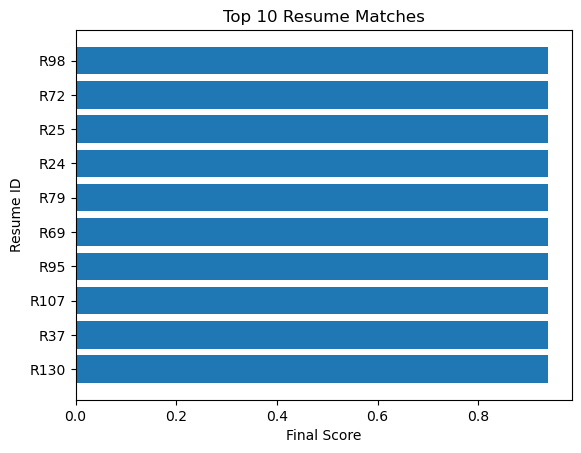

In [26]:
import matplotlib.pyplot as plt

# Sort by final score
top10 = res.sort_values(by="final_score", ascending=False).head(10)

# Plot
plt.figure()
plt.barh(top10["resume_id"], top10["final_score"])
plt.xlabel("Final Score")
plt.ylabel("Resume ID")
plt.title("Top 10 Resume Matches")
plt.gca().invert_yaxis()
plt.show()
